In [193]:
import zeus21
import eMCMC
import estats
from matplotlib.ticker import MaxNLocator
import eplots
Plotting = eplots.Plotting()
import importlib

In [45]:
# Get data
datBouw21 = np.loadtxt('/Users/eb35267/Desktop/research/data/Bouwens2021_GAL.txt',  skiprows=2, unpack=True)
redshiftsBouw21 = np.unique(datBouw21[0])
dredshiftsBouw21 = np.ones_like(redshiftsBouw21)/2. #approximate, there are true window functions to use

datHST = [] 
#format is     zdat = data[0] zerr = data[1] xdat = data[2],  ydat = data[3]  yerr = data[4]  xerr = data[5] 

for iz,z in enumerate(redshiftsBouw21): # Create a bunch of arrays that contain all of the data listed above. One for each redshift
    zlistindex = datBouw21[0] == 1.0*z
    datarr = [z,dredshiftsBouw21[iz], datBouw21[1][zlistindex], datBouw21[3][zlistindex], datBouw21[4][zlistindex], datBouw21[2][zlistindex]]
    datHST= datHST + [datarr]

In [320]:
# Set hyperparameters
scale = 1000
# labels = [r'$\log(M_c)$', r'$d\log(M_c)/dz$', r"$\alpha$", r"$d\alpha/dz$", r"$\beta$", 
#           r"$d\beta/dz$", r"$\log(\epsilon_0)$", r'$d\log(\epsilon_0)/dz$', r'$\sigma_{\rm{UV}}$', r'$d\sigma_{\rm{UV}}/dz$', 
#           r'$d\sigma_{\rm{UV}}/dM_{\rm{UV}}$']
labels = [r'$\log(M_c)$', r"$\alpha$", r"$\beta$", r"$\log(\epsilon_0)$", r'$\sigma_{\rm{UV}, 0}$', r'$d\sigma_{\rm{UV}}/dM_{\rm{UV}}$']
params1 = [12, 0.6, -0.5, -1, 0, 0.01*scale]
lowers = [9, 0, -4,  -5, 0, -.2*scale]
uppers = [16, 4, 0, 1, 3, .2*scale]

In [321]:
# Initalize class
my_UVLF = eMCMC.UVLF(datHST, params1, lowers, uppers, scale=scale, time_dependence = False, piecewise_eps = False, piecewise_sig = False)

In [322]:
# Get initial positions for all the walkers by running a short MCMC
ICs = my_UVLF.generate_ICs()

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


In [323]:
# Run MCMC
Nsteps=2000
my_UVLF.sampler.run_mcmc(ICs, Nsteps) 
# Get flat sample from the MCMC
samples = my_UVLF.sampler.get_chain(discard = 400, flat=True)

In [324]:
samples[:,-1] = samples[:,-1]/scale

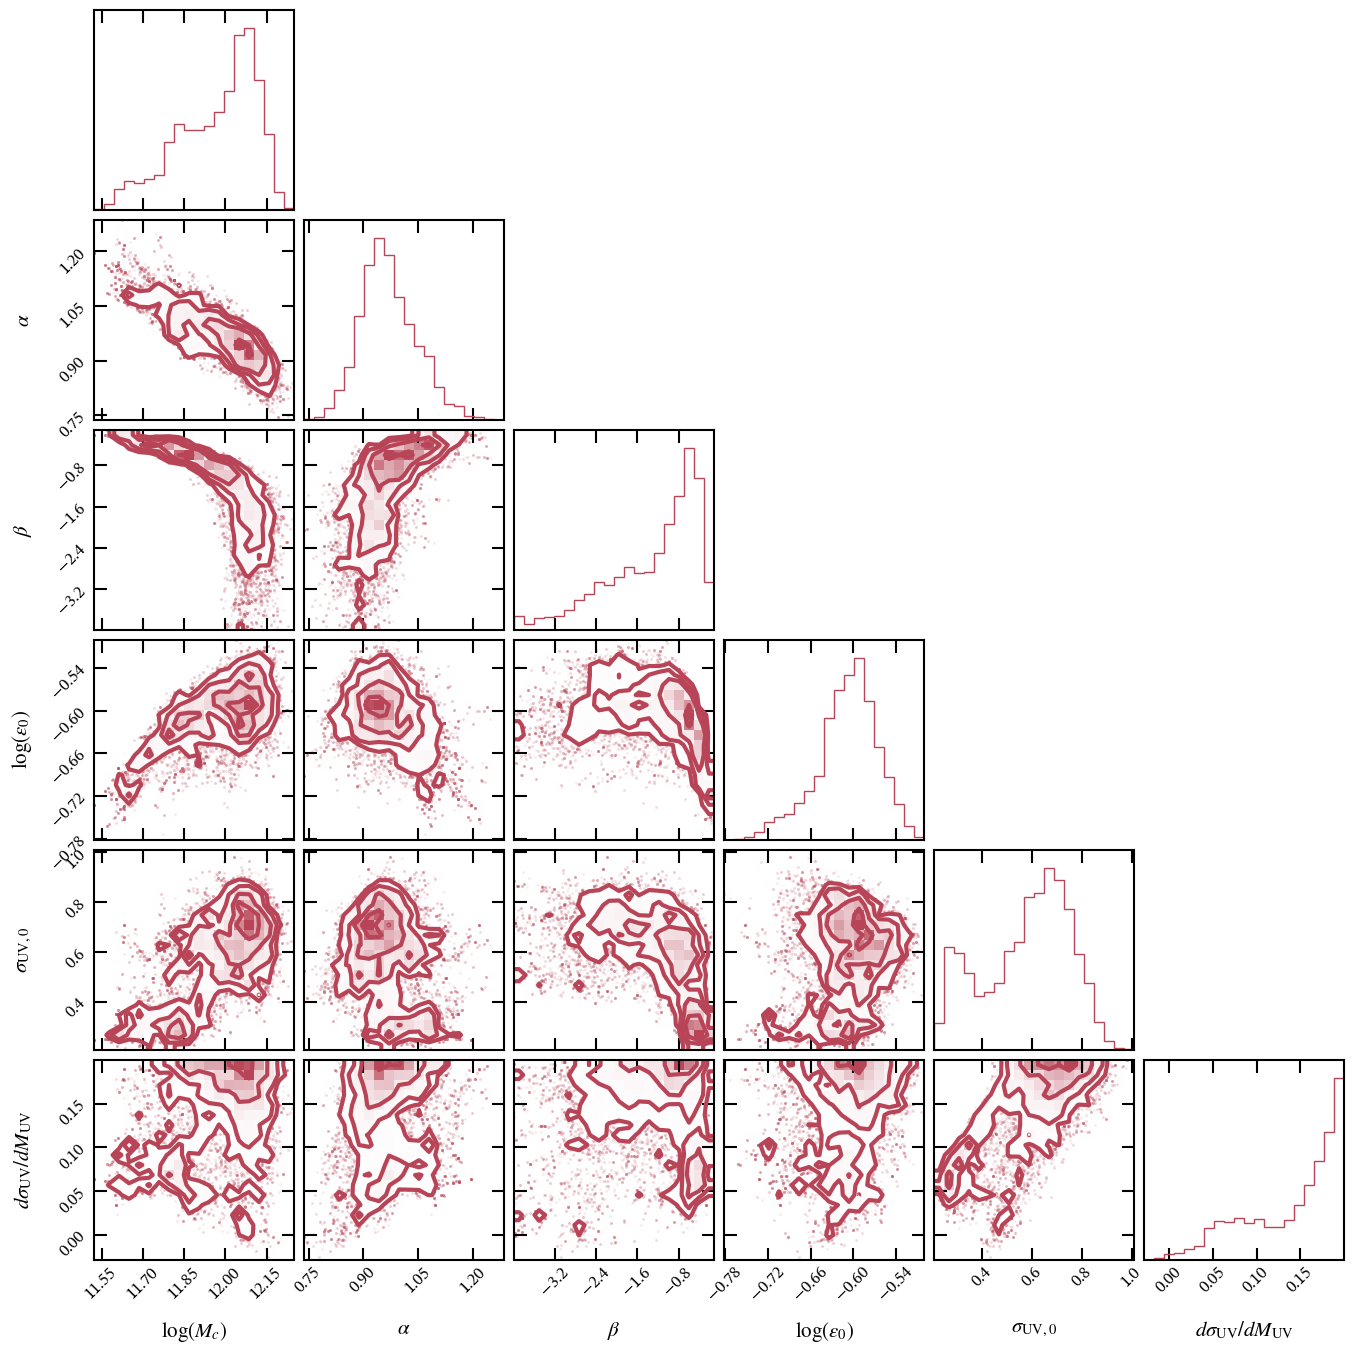

In [325]:
corner = Plotting.plot_corner(samples, labels)

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:29: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude


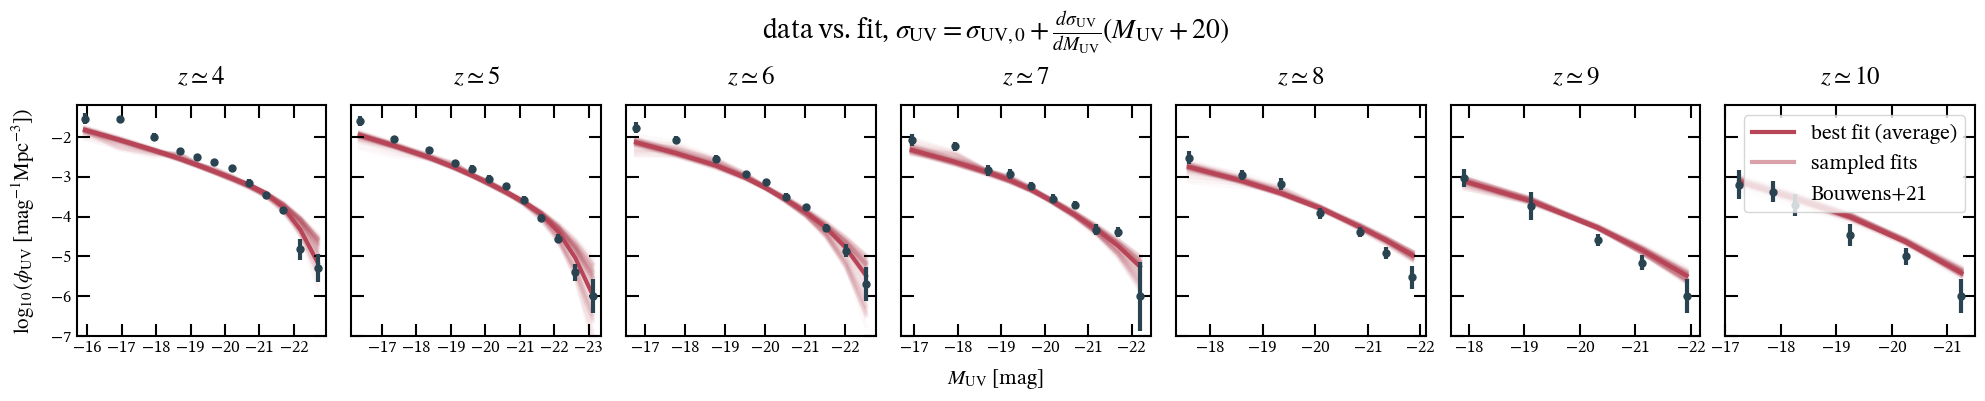

In [326]:
ev_sig = Plotting.plot_evolving_UVLF_fit(samples, my_UVLF, 
        title = r'data vs. fit, $\sigma_{\rm{UV}} = \sigma_{\rm{UV}, 0} + \frac{d\sigma_{\rm{UV}}}{dM_{\rm{UV}}}(M_{\rm{UV}} + 20)$')

# <span style = 'color:red'> Test sigma(M): <span>

In [50]:
z = datHST[0][0]
zwidth = datHST[0][1]
MUVcenters = datHST[0][2]
MUVwidth = datHST[0][5]
ydat = datHST[0][3]
yerr = datHST[0][4]

In [27]:
CosmoParams_input = zeus21.Cosmo_Parameters_Input(zmin_CLASS=0.0)
CosmoParams, _, _, HMFintclass =  zeus21.cosmo_wrapper(CosmoParams_input)

In [187]:
astroparams_test = zeus21.Astro_Parameters(CosmoParams,epsstar=10**params1[6], Mc=10**params1[0],alphastar=params1[2], betastar=params1[4], 
                                      sigmaUV = (-(MUVcenters+13)/6).reshape(-1,1))
UVLF_test = zeus21.UVLFs.UVLF_binned(astroparams_test,CosmoParams,HMFintclass,z,zwidth,MUVcenters,MUVwidth)

In [188]:
astroparams_std = zeus21.Astro_Parameters(CosmoParams,epsstar=10**params1[6], Mc=10**params1[0],alphastar=params1[2], betastar=params1[4], 
                                      sigmaUV = 1) 
UVLF_std = zeus21.UVLFs.UVLF_binned(astroparams_std,CosmoParams,HMFintclass,z,zwidth,MUVcenters,MUVwidth)

<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_82319/926464947.py:22: SyntaxWarning: invalid escape sequence '\s'
  fig.text(.5, 1.05, f'$z \simeq {int(z)}$', ha = 'center', fontsize = 20)


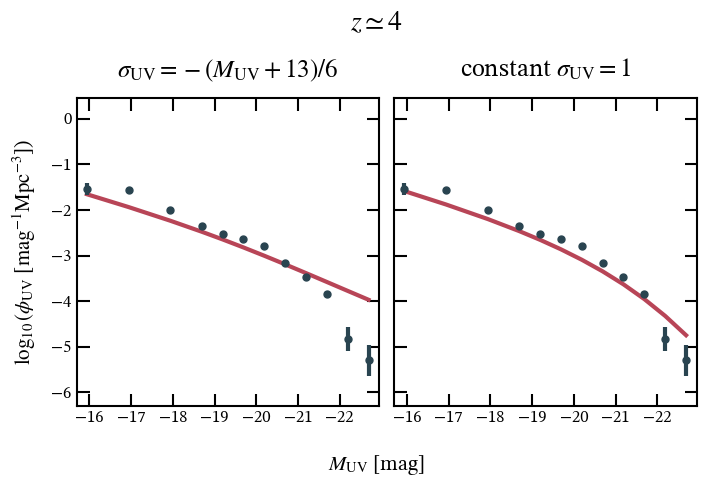

In [192]:
fig, ax = plt.subplots(1, 2, sharey = True)
fig.set_size_inches((8,4))

ax[0].plot(MUVcenters, np.log10(UVLF_test))
ax[1].plot(MUVcenters, np.log10(UVLF_std))


ax[0].set_ylim(np.log10(np.min(ydat))-1, np.log10(np.max(ydat))+2)

for ax_i in ax: 
    ax_i.errorbar(MUVcenters, np.log10(ydat), estats.calc_log_error(ydat, yerr), fmt = ".", capsize=0, markersize = 10, 
                   color = Plotting.navy)
    ax_i.invert_xaxis()
    ax_i.set_xlim(np.max(MUVcenters)+0.25, np.min(MUVcenters)-0.25)
    ax_i.xaxis.set_major_locator(MaxNLocator(integer=True)) # Make it so that only integers can be used in the axis labels

ax[0].set_ylabel(r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])')
ax[0].set_title(r'$\sigma_{\rm{UV}} = -(M_{\rm{UV}}+13)/6$')
ax[1].set_title(r'constant $\sigma_{\rm{UV}} = 1$')

fig.text(.5, -0.05, r'$M_{\rm{UV}}$ [mag]', ha = 'center')
fig.text(.5, 1.05, f'$z \simeq {int(z)}$', ha = 'center', fontsize = 20)

fig.savefig('/Users/eb35267/Desktop/figures/ongoing/sigma(M_h).png', bbox_inches = 'tight')

In [191]:
save_dir

'/Users/eb35267/Desktop/figures'